In [5]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
optical_recognition_of_handwritten_digits = fetch_ucirepo(id=80) 
  
# data (as pandas dataframes) 
X = optical_recognition_of_handwritten_digits.data.features 
y = optical_recognition_of_handwritten_digits.data.targets 
  
# metadata 
print(optical_recognition_of_handwritten_digits.metadata) 
  
# variable information 
print(optical_recognition_of_handwritten_digits.variables) 


{'uci_id': 80, 'name': 'Optical Recognition of Handwritten Digits', 'repository_url': 'https://archive.ics.uci.edu/dataset/80/optical+recognition+of+handwritten+digits', 'data_url': 'https://archive.ics.uci.edu/static/public/80/data.csv', 'abstract': 'Two versions of this database available; see folder', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 5620, 'num_features': 64, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Wed Aug 23 2023', 'dataset_doi': '10.24432/C50P49', 'creators': ['E. Alpaydin', 'C. Kaynak'], 'intro_paper': {'ID': 280, 'type': 'NATIVE', 'title': 'Methods of Combining Multiple Classifiers and Their Applications to Handwritten Digit Recognition', 'authors': 'C. Kaynak', 'venue': 'MSc Thesis, Institute of Graduate Studies in Science and Engineering, 

In [6]:
from ucimlrepo import fetch_ucirepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [7]:
dataset = fetch_ucirepo(id=80)

X = dataset.data.features
y = dataset.data.targets


In [8]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (5620, 64)
Shape of y: (5620, 1)


In [9]:
print(X.head())

   Attribute1  Attribute2  Attribute3  Attribute4  Attribute5  Attribute6  \
0           0           1           6          15          12           1   
1           0           0          10          16           6           0   
2           0           0           8          15          16          13   
3           0           0           0           3          11          16   
4           0           0           5          14           4           0   

   Attribute7  Attribute8  Attribute9  Attribute10  ...  Attribute55  \
0           0           0           0            7  ...            0   
1           0           0           0            7  ...            3   
2           0           0           0            1  ...            0   
3           0           0           0            0  ...            0   
4           0           0           0            0  ...           12   

   Attribute56  Attribute57  Attribute58  Attribute59  Attribute60  \
0            0            0       

In [10]:
print("\nDataset information:")
print(X.info())


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 5620 entries, 0 to 5619
Data columns (total 64 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Attribute1   5620 non-null   int64
 1   Attribute2   5620 non-null   int64
 2   Attribute3   5620 non-null   int64
 3   Attribute4   5620 non-null   int64
 4   Attribute5   5620 non-null   int64
 5   Attribute6   5620 non-null   int64
 6   Attribute7   5620 non-null   int64
 7   Attribute8   5620 non-null   int64
 8   Attribute9   5620 non-null   int64
 9   Attribute10  5620 non-null   int64
 10  Attribute11  5620 non-null   int64
 11  Attribute12  5620 non-null   int64
 12  Attribute13  5620 non-null   int64
 13  Attribute14  5620 non-null   int64
 14  Attribute15  5620 non-null   int64
 15  Attribute16  5620 non-null   int64
 16  Attribute17  5620 non-null   int64
 17  Attribute18  5620 non-null   int64
 18  Attribute19  5620 non-null   int64
 19  Attribute20  5620 non-null   int64
 2

In [11]:
print("\nMissing values:")
print(X.isnull().sum().sum())


Missing values:
0


In [12]:
X = X.fillna(X.median())

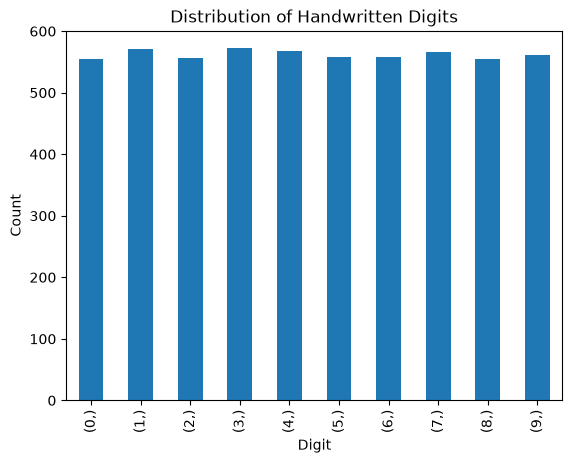

In [15]:
import matplotlib.pyplot as plt

y.value_counts().sort_index().plot(kind="bar")

plt.xlabel("Digit")
plt.ylabel("Count")
plt.title("Distribution of Handwritten Digits")

plt.show()

In [16]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nStandardized data shape:", X_scaled.shape)


Standardized data shape: (5620, 64)


In [17]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

In [18]:
explained_variance = pca.explained_variance_ratio_

print("\nExplained variance ratio:")
print(explained_variance)



Explained variance ratio:
[0.11605858 0.10170154 0.07802196 0.05838575 0.04872878 0.04443165
 0.03858777 0.03396881 0.02847027 0.02664077 0.02579526 0.02396405
 0.02296419 0.02096637 0.01985408 0.01925913 0.01839588 0.01791107
 0.01611019 0.01536702 0.01440333 0.01351333 0.01263442 0.01137331
 0.01027003 0.01013637 0.009843   0.00924277 0.00878745 0.00823775
 0.00805148 0.0073072  0.00712056 0.00630496 0.0061604  0.00603571
 0.00555209 0.00513331 0.00494935 0.00452421 0.00438713 0.00410619
 0.00393405 0.00351003 0.00344296 0.00327169 0.00315703 0.00287722
 0.00265991 0.00260422 0.00250353 0.00241976 0.00221433 0.00206632
 0.00189532 0.00184898 0.00167358 0.00157842 0.00143361 0.00126219
 0.00104638 0.00094303 0.         0.        ]


In [19]:
cumulative_variance = np.cumsum(explained_variance)

print("\nCumulative explained variance:")
print(cumulative_variance)


Cumulative explained variance:
[0.11605858 0.21776012 0.29578208 0.35416783 0.40289661 0.44732826
 0.48591603 0.51988484 0.54835511 0.57499588 0.60079113 0.62475518
 0.64771937 0.66868574 0.68853981 0.70779894 0.72619482 0.74410589
 0.76021608 0.7755831  0.78998642 0.80349975 0.81613417 0.82750748
 0.83777752 0.84791389 0.85775688 0.86699965 0.8757871  0.88402485
 0.89207633 0.89938353 0.90650409 0.91280906 0.91896946 0.92500517
 0.93055726 0.93569057 0.94063992 0.94516412 0.94955125 0.95365744
 0.95759149 0.96110151 0.96454448 0.96781617 0.9709732  0.97385042
 0.97651033 0.97911455 0.98161809 0.98403785 0.98625218 0.9883185
 0.99021382 0.9920628  0.99373637 0.99531479 0.9967484  0.99801059
 0.99905697 1.         1.         1.        ]


Text(0.5, 1.0, 'Explained Variance by Principal Components')

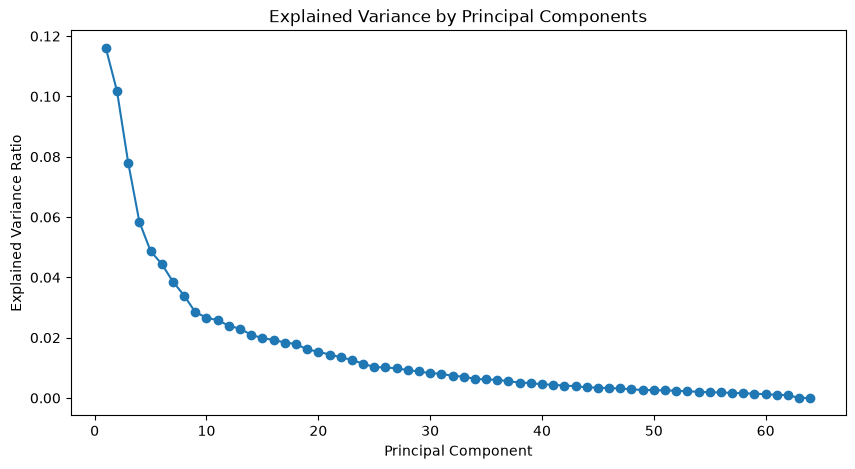

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker='o'
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by Principal Components")

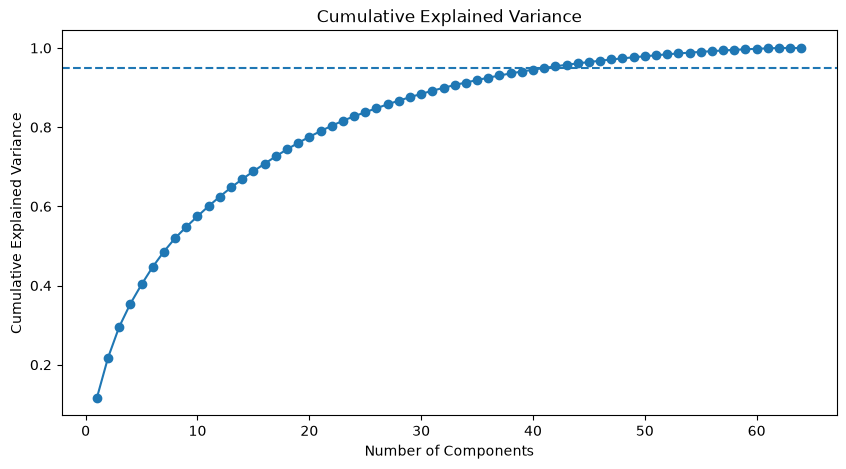

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)
plt.axhline(
    y=0.95,
    linestyle='--'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.show()


In [22]:
n_components = np.argmax(cumulative_variance >= 0.95) + 1

print("\nNumber of components for 95% variance:", n_components)


Number of components for 95% variance: 42


In [23]:
pca_reduced = PCA(n_components=n_components)

X_reduced = pca_reduced.fit_transform(X_scaled)

print("\nOriginal dimensions:", X.shape[1])
print("Reduced dimensions:", X_reduced.shape[1])
print("Reduced data shape:", X_reduced.shape)


Original dimensions: 64
Reduced dimensions: 42
Reduced data shape: (5620, 42)


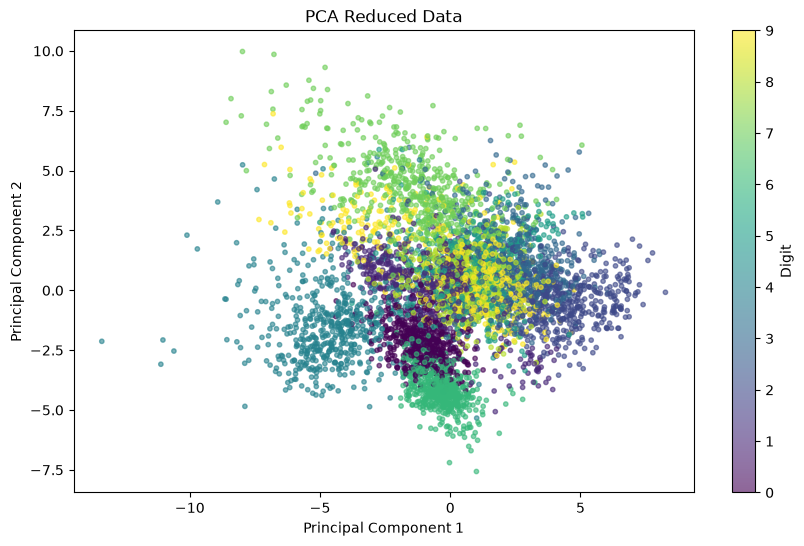

In [24]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    c=y.values.ravel(),
    s=10,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Reduced Data")

plt.colorbar(label="Digit")

plt.show()